# Extra analysis and visualisations

## 1. Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from pathlib import Path


sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

file_path = Path("data/Dataset3_PortfolioReplicaStrategy.xlsx")
data_raw = pd.read_excel(file_path)

data_raw = data_raw.rename(columns={data_raw.columns[0]: "Date"})

raw_tickers = data_raw.columns[1:].tolist()

full_names = [
    "MSCI World",
    "MSCI ACWI",
    "Bloomberg Global Aggregate",
    "HFRX Global Hedge Fund",
    "Euro-Bund Future",
    "US 10yr Note Future",
    "Gold Future",
    "Brent Crude Future",
    "S&P 500 Future",
    "Euro Stoxx 50 Future",
    "Nasdaq 100 Future",
    "Lead Future",
    "Topix Future",
    "Euro-Schatz Future",
    "US 2yr Note Future"
]

suffixes = [
    " Index", " Index", " Index", " Index",
    " Comdty", " Comdty", " Comdty", " Comdty",
    " Comdty", " Comdty", " Comdty", " Comdty",
    " Comdty", " Comdty", " Comdty"
]

if len(raw_tickers) != len(full_names):
    raise ValueError("Mismatch between raw tickers and full names.")

if len(raw_tickers) != len(suffixes):
    raise ValueError("Mismatch between raw tickers and suffixes.")

tickers = [ticker + suffix for ticker, suffix in zip(raw_tickers, suffixes)]

data_raw.columns = ["Date"] + tickers

variable_info = dict(zip(tickers, full_names))

data_raw["Date"] = pd.to_datetime(data_raw["Date"], errors="coerce")
data = data_raw.set_index("Date")
data = data.sort_index()

data = data.apply(pd.to_numeric, errors="coerce")



## 2. Alternative synthetic targets and their analysis


In [38]:
new_target_definitions = {
    "Balanced Index Tracking": {
        "MXWD Index": 0.60,
        "LEGATRUU Index": 0.40
    },
    "UCITS Clone": {
        "HFRXGL Index": 0.50,
        "MXWD Index": 0.25,
        "LEGATRUU Index": 0.25
    },
    "Risk Management Target": {
        "HFRXGL Index": 0.40,
        "MXWD Index": 0.40,
        "LEGATRUU Index": 0.20
    },
    "Final target":  {
    "HFRXGL Index": 0.7,    # Hedge Fund / alternative exposure
    "MXWD Index": 0.15,      # Global equity exposure
    "LEGATRUU Index": 0.15   # Global bond exposure
}

}

# Check that the weights of each target sum to 1
for target_name, weights in new_target_definitions.items():
    total_weight = sum(weights.values())
    
    if not np.isclose(total_weight, 1.0):
        raise ValueError(
            f"Weights for {target_name} do not sum to 1. Current sum: {total_weight:.4f}"
        )

print("All target weights sum to 1.")

# Display the composition of the new synthetic targets
new_target_composition = pd.DataFrame(new_target_definitions).fillna(0).T

new_target_composition_display = new_target_composition.copy()

for col in new_target_composition_display.columns:
    new_target_composition_display[col] = new_target_composition_display[col].map(
        lambda x: f"{x * 100:.0f}%"
    )

print("New synthetic targets - composition:")
display(new_target_composition_display)

All target weights sum to 1.
New synthetic targets - composition:


,MXWD Index,LEGATRUU Index,HFRXGL Index
Balanced Index Tracking,60%,40%,0%
UCITS Clone,25%,25%,50%
Risk Management Target,40%,20%,40%
Final target,15%,15%,70%


New synthetic targets - composition:


,MXWD Index,LEGATRUU Index,HFRXGL Index
Balanced Index Tracking,60%,40%,0%
UCITS Clone,25%,25%,50%
Risk Management Target,40%,20%,40%
Final target,15%,15%,70%



 RUNNING ANALYSIS FOR TARGET: BALANCED INDEX TRACKING 

[Balanced Index Tracking] Synthetic target statistics:


,Value
Metric,
Annualized Return,4.65%
Annualized Volatility,11.33%
Sharpe Ratio,0.41
Max Drawdown,-39.98%
Weekly VaR 95%,-2.39%
Weekly Expected Shortfall 95%,-3.87%
Skewness,-0.63
Kurtosis,5.42


[Balanced Index Tracking] Target vs underlying components:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
MXWD Index,5.51%,17.78%,0.31,-58.39%,-3.81%,-6.21%,-0.64,4.66
LEGATRUU Index,3.37%,5.34%,0.63,-10.41%,-1.08%,-1.62%,-0.33,4.12
Synthetic Target,4.65%,11.33%,0.41,-39.98%,-2.39%,-3.87%,-0.63,5.42


[Balanced Index Tracking] Synthetic target portfolio composition:


,Component,Description,Weight
0,MXWD Index,MSCI ACWI,60%
1,LEGATRUU Index,Bloomberg Global Aggregate,40%


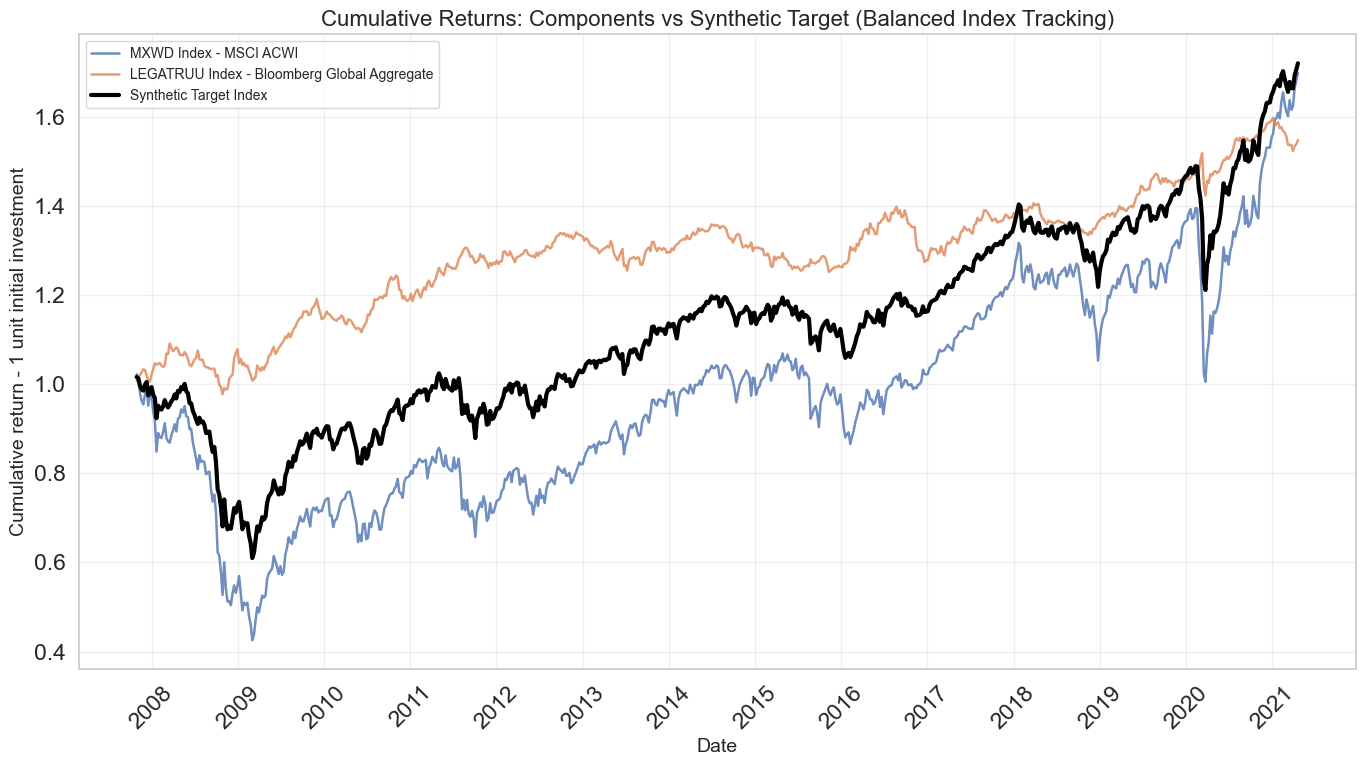

[Balanced Index Tracking] Correlation between synthetic target and futures:


,Correlation with Target
ES1 Comdty,0.894
VG1 Comdty,0.812
NQ1 Comdty,0.802
TP1 Comdty,0.626
LLL1 Comdty,0.599
CO1 Comdty,0.462
DU1 Comdty,-0.323
GC1 Comdty,0.257
RX1 Comdty,-0.213
TY1 Comdty,-0.174



 RUNNING ANALYSIS FOR TARGET: UCITS CLONE 

[UCITS Clone] Synthetic target statistics:


,Value
Metric,
Annualized Return,2.47%
Annualized Volatility,6.41%
Sharpe Ratio,0.38
Max Drawdown,-29.27%
Weekly VaR 95%,-1.30%
Weekly Expected Shortfall 95%,-2.28%
Skewness,-1.32
Kurtosis,7.55


[UCITS Clone] Target vs underlying components:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
HFRXGL Index,0.50%,4.78%,0.10,-24.91%,-1.06%,-1.84%,-2.30,13.70
MXWD Index,5.51%,17.78%,0.31,-58.39%,-3.81%,-6.21%,-0.64,4.66
LEGATRUU Index,3.37%,5.34%,0.63,-10.41%,-1.08%,-1.62%,-0.33,4.12
Synthetic Target,2.47%,6.41%,0.38,-29.27%,-1.30%,-2.28%,-1.32,7.55


[UCITS Clone] Synthetic target portfolio composition:


,Component,Description,Weight
0,HFRXGL Index,HFRX Global Hedge Fund,50%
1,MXWD Index,MSCI ACWI,25%
2,LEGATRUU Index,Bloomberg Global Aggregate,25%


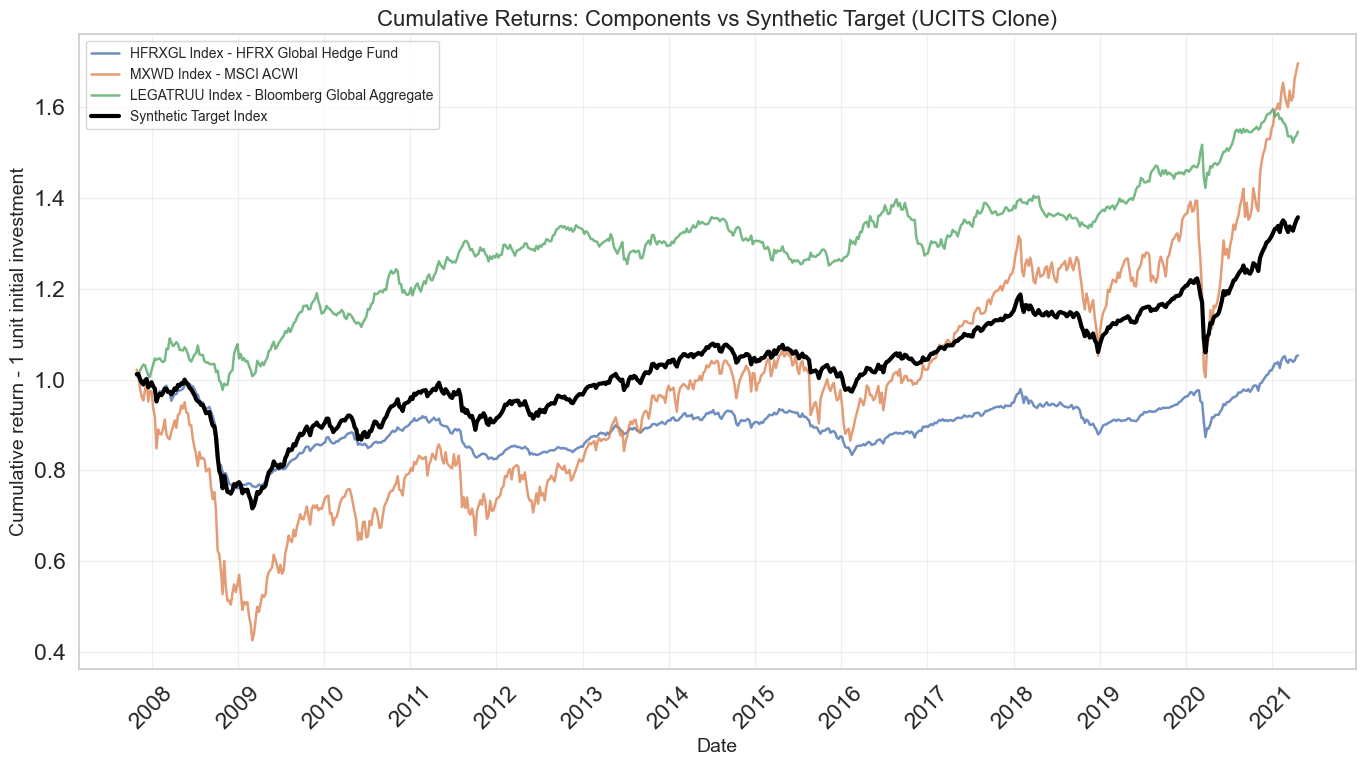

[UCITS Clone] Correlation between synthetic target and futures:


,Correlation with Target
ES1 Comdty,0.828
NQ1 Comdty,0.739
VG1 Comdty,0.728
TP1 Comdty,0.602
LLL1 Comdty,0.512
CO1 Comdty,0.447
DU1 Comdty,-0.262
GC1 Comdty,0.227
TU2 Comdty,-0.150
RX1 Comdty,-0.129



 RUNNING ANALYSIS FOR TARGET: RISK MANAGEMENT TARGET 

[Risk Management Target] Synthetic target statistics:


,Value
Metric,
Annualized Return,3.08%
Annualized Volatility,8.51%
Sharpe Ratio,0.36
Max Drawdown,-36.05%
Weekly VaR 95%,-1.84%
Weekly Expected Shortfall 95%,-3.00%
Skewness,-1.03
Kurtosis,6.02


[Risk Management Target] Target vs underlying components:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
HFRXGL Index,0.50%,4.78%,0.10,-24.91%,-1.06%,-1.84%,-2.30,13.70
MXWD Index,5.51%,17.78%,0.31,-58.39%,-3.81%,-6.21%,-0.64,4.66
LEGATRUU Index,3.37%,5.34%,0.63,-10.41%,-1.08%,-1.62%,-0.33,4.12
Synthetic Target,3.08%,8.51%,0.36,-36.05%,-1.84%,-3.00%,-1.03,6.02


[Risk Management Target] Synthetic target portfolio composition:


,Component,Description,Weight
0,HFRXGL Index,HFRX Global Hedge Fund,40%
1,MXWD Index,MSCI ACWI,40%
2,LEGATRUU Index,Bloomberg Global Aggregate,20%


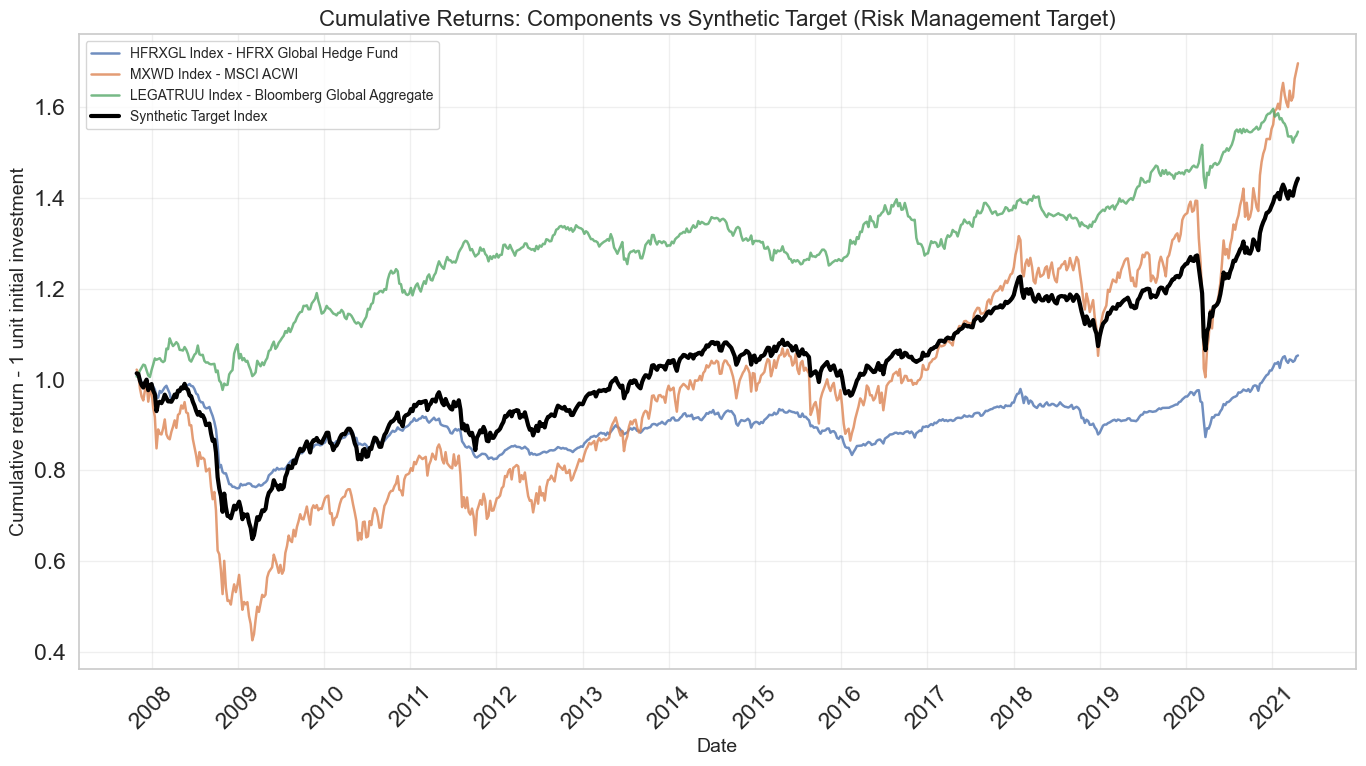

[Risk Management Target] Correlation between synthetic target and futures:


,Correlation with Target
ES1 Comdty,0.889
NQ1 Comdty,0.798
VG1 Comdty,0.796
TP1 Comdty,0.649
LLL1 Comdty,0.566
CO1 Comdty,0.471
DU1 Comdty,-0.313
GC1 Comdty,0.209
TU2 Comdty,-0.203
RX1 Comdty,-0.200



 RUNNING ANALYSIS FOR TARGET: FINAL TARGET 

[Final target] Synthetic target statistics:


,Value
Metric,
Annualized Return,1.68%
Annualized Volatility,5.42%
Sharpe Ratio,0.31
Max Drawdown,-27.31%
Weekly VaR 95%,-1.16%
Weekly Expected Shortfall 95%,-2.00%
Skewness,-1.80
Kurtosis,9.58


[Final target] Target vs underlying components:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
HFRXGL Index,0.50%,4.78%,0.10,-24.91%,-1.06%,-1.84%,-2.30,13.70
MXWD Index,5.51%,17.78%,0.31,-58.39%,-3.81%,-6.21%,-0.64,4.66
LEGATRUU Index,3.37%,5.34%,0.63,-10.41%,-1.08%,-1.62%,-0.33,4.12
Synthetic Target,1.68%,5.42%,0.31,-27.31%,-1.16%,-2.00%,-1.80,9.58


[Final target] Synthetic target portfolio composition:


,Component,Description,Weight
0,HFRXGL Index,HFRX Global Hedge Fund,70%
1,MXWD Index,MSCI ACWI,15%
2,LEGATRUU Index,Bloomberg Global Aggregate,15%


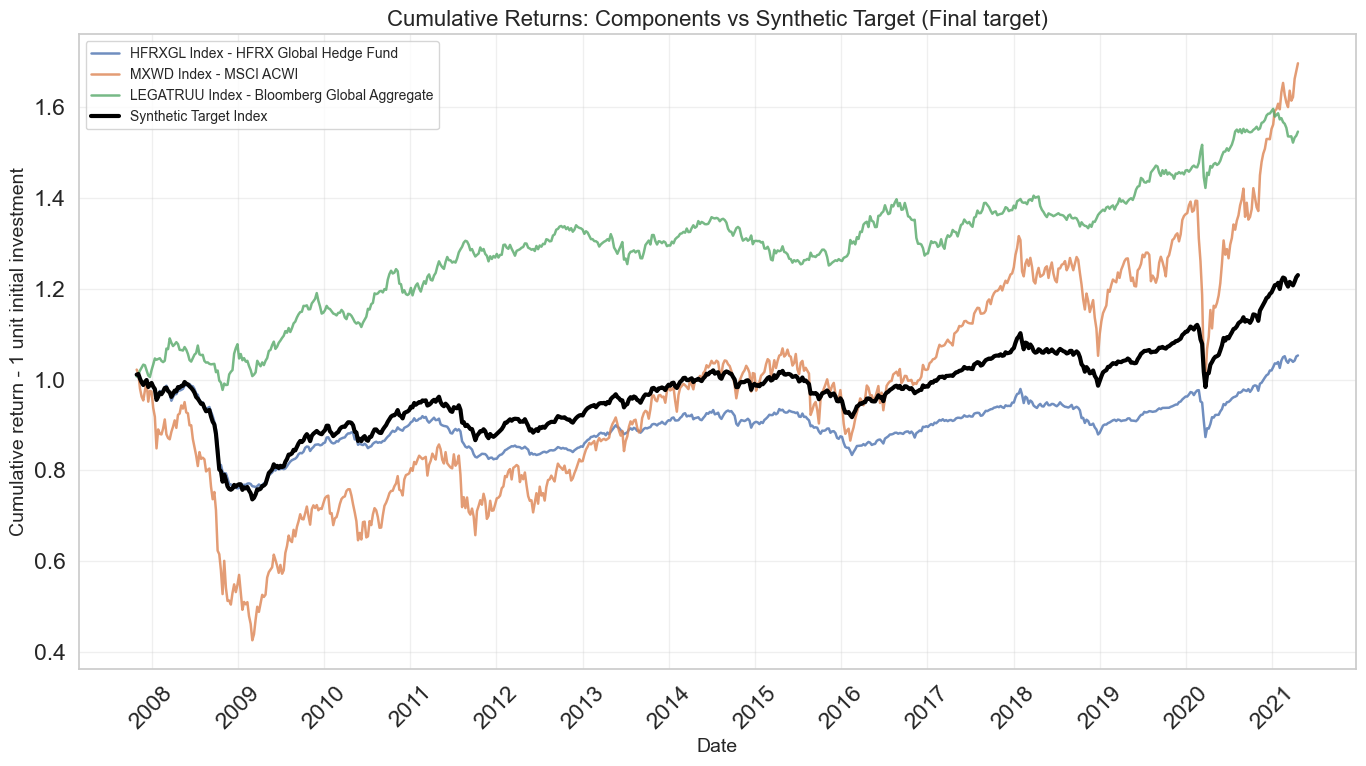

[Final target] Correlation between synthetic target and futures:


,Correlation with Target
ES1 Comdty,0.744
NQ1 Comdty,0.663
VG1 Comdty,0.637
TP1 Comdty,0.567
LLL1 Comdty,0.425
CO1 Comdty,0.416
DU1 Comdty,-0.218
GC1 Comdty,0.164
TU2 Comdty,-0.163
TY1 Comdty,-0.109


In [39]:
# Display the composition of the new synthetic targets
new_target_composition = pd.DataFrame(new_target_definitions).fillna(0).T
new_target_composition_display = new_target_composition.copy()

for col in new_target_composition_display.columns:
    new_target_composition_display[col] = new_target_composition_display[col].map(
        lambda x: f"{x * 100:.0f}%"
    )

print("New synthetic targets - composition:")
display(new_target_composition_display)

def max_drawdown(x):
    cumulative = (1 + x).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    return drawdown.min()

# Futures used as replicating instruments
futures_contracts = [
    "RX1 Comdty", "TY1 Comdty", "GC1 Comdty", "CO1 Comdty",
    "ES1 Comdty", "VG1 Comdty", "NQ1 Comdty", "LLL1 Comdty",
    "TP1 Comdty", "DU1 Comdty", "TU2 Comdty"
]

# Static Safety Check: Verify futures exist before entering the loop
missing_futures = [col for col in futures_contracts if col not in data.columns]
if missing_futures:
    raise ValueError(f"Missing futures columns: {missing_futures}")

# Compute weekly returns for futures once globally
futures_returns_master = data[futures_contracts].pct_change(fill_method=None).dropna()


# ==========================================
# LOOP THROUGH EACH TARGET FOR FULL ANALYSIS
# ==========================================
for target_name, target_components in new_target_definitions.items():
    print("\n" + "="*60)
    print(f" RUNNING ANALYSIS FOR TARGET: {target_name.upper()} ")
    print("="*60 + "\n")
    
    # Dynamic Safety Check: Verify current target components exist
    missing_target_components = [col for col in target_components.keys() if col not in data.columns]
    if missing_target_components:
        raise ValueError(f"Missing target component columns for {target_name}: {missing_target_components}")

    # Compute weekly returns for components
    component_returns = data[list(target_components.keys())].pct_change(fill_method=None).dropna()

    # Create the synthetic target index returns 
    target_returns = pd.Series(0, index=component_returns.index, dtype=float)

    for component, weight in target_components.items():
        target_returns += component_returns[component] * weight

    target_returns.name = "Target_Index"

    # Align target and futures on common dates 
    common_dates = target_returns.index.intersection(futures_returns_master.index)
    target_returns_aligned = target_returns.loc[common_dates]
    futures_returns = futures_returns_master.loc[common_dates]

    # Summary statistics for the synthetic target
    target_var_95 = target_returns_aligned.quantile(0.05)
    target_es_95 = target_returns_aligned[
        target_returns_aligned <= target_var_95
    ].mean()

    target_stats_raw = {
        "Annualized Return": target_returns_aligned.mean() * 52,
        "Annualized Volatility": target_returns_aligned.std() * np.sqrt(52),
        "Sharpe Ratio": (
            target_returns_aligned.mean() * 52
        ) / (
            target_returns_aligned.std() * np.sqrt(52)
        ),
        "Max Drawdown": max_drawdown(target_returns_aligned),
        "Weekly VaR 95%": target_var_95,
        "Weekly Expected Shortfall 95%": target_es_95,
        "Skewness": target_returns_aligned.skew(),
        "Kurtosis": target_returns_aligned.kurtosis()
    }

    percentage_metrics = [
        "Annualized Return",
        "Annualized Volatility",
        "Max Drawdown",
        "Weekly VaR 95%",
        "Weekly Expected Shortfall 95%"
    ]

    formatted_values = {}
    for metric, value in target_stats_raw.items():
        if metric in percentage_metrics:
            formatted_values[metric] = f"{value * 100:.2f}%"
        else:
            formatted_values[metric] = f"{value:.2f}"

    target_stats_display = pd.DataFrame.from_dict(
        formatted_values,
        orient="index",
        columns=["Value"]
    )
    target_stats_display.index.name = "Metric"

    print(f"[{target_name}] Synthetic target statistics:")
    display(target_stats_display)

    # Target vs components comparison
    target_and_components = component_returns.loc[common_dates].copy()
    target_and_components["Synthetic Target"] = target_returns_aligned

    comparison_raw = pd.DataFrame({
        "Ann. Return": target_and_components.mean() * 52,
        "Ann. Volatility": target_and_components.std() * np.sqrt(52),
        "Sharpe Ratio": (
            target_and_components.mean() * 52
        ) / (
            target_and_components.std() * np.sqrt(52)
        ),
        "Max Drawdown": target_and_components.apply(max_drawdown),
        "Weekly VaR 95%": target_and_components.quantile(0.05),
        "Weekly Expected Shortfall 95%": target_and_components.apply(
            lambda x: x[x <= x.quantile(0.05)].mean()
        ),
        "Skewness": target_and_components.skew(),
        "Kurtosis": target_and_components.kurtosis()
    })

    comparison_display = comparison_raw.copy()
    percentage_cols = [
        "Ann. Return",
        "Ann. Volatility",
        "Max Drawdown",
        "Weekly VaR 95%",
        "Weekly Expected Shortfall 95%"
    ]

    for col in percentage_cols:
        comparison_display[col] = comparison_display[col].map(lambda x: f"{x * 100:.2f}%")

    for col in ["Sharpe Ratio", "Skewness", "Kurtosis"]:
        comparison_display[col] = comparison_display[col].map(lambda x: f"{x:.2f}")

    print(f"[{target_name}] Target vs underlying components:")
    display(comparison_display)

    # Display target composition 
    target_weights = pd.DataFrame({
        "Component": list(target_components.keys()),
        "Description": [variable_info.get(k, k) for k in target_components.keys()],
        "Weight": list(target_components.values())
    })
    target_weights["Weight"] = target_weights["Weight"].map(lambda x: f"{x:.0%}")

    print(f"[{target_name}] Synthetic target portfolio composition:")
    display(target_weights)

    # Plot cumulative performance of target components and synthetic target 
    target_cumulative = (1 + target_returns_aligned).cumprod()
    components_cumulative = (1 + component_returns.loc[common_dates]).cumprod()

    plt.figure(figsize=(14, 8))

    for col in components_cumulative.columns:
        plt.plot(
            components_cumulative.index,
            components_cumulative[col],
            linewidth=1.8,
            alpha=0.8,
            label=f"{col} - {variable_info.get(col, col)}"
        )

    plt.plot(
        target_cumulative.index,
        target_cumulative,
        linewidth=3,
        color="black",
        label="Synthetic Target Index"
    )

    plt.title(f"Cumulative Returns: Components vs Synthetic Target ({target_name})", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Cumulative return - 1 unit initial investment", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize=10)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Correlation between target and futures 
    correlations = pd.DataFrame(index=futures_contracts)

    correlations["Correlation with Target"] = [
        target_returns_aligned.corr(futures_returns[contract])
        for contract in futures_contracts
    ]

    correlations["Abs Correlation"] = correlations["Correlation with Target"].abs()
    correlations = correlations.sort_values("Abs Correlation", ascending=False)

    print(f"[{target_name}] Correlation between synthetic target and futures:")
    display(correlations[["Correlation with Target"]].round(3))

In [40]:
# Build weekly returns for each new synthetic target
new_targets_returns = pd.DataFrame(index=component_returns.index)

for target_name, weights in new_target_definitions.items():
    target_series = pd.Series(0.0, index=component_returns.index)
    
    for component, weight in weights.items():
        target_series += component_returns[component] * weight
    
    new_targets_returns[target_name] = target_series

# Align with the same dates used for the main synthetic target and futures
new_targets_returns = new_targets_returns.loc[common_dates]

print("New synthetic targets - weekly returns preview:")
display(new_targets_returns.head())



New synthetic targets - weekly returns preview:


,Balanced Index Tracking,UCITS Clone,Risk Management Target,Final target
Date,,,,
2007-10-30,0.015871,0.011967,0.013978,0.011021
2007-11-06,-0.003461,0.000297,-0.001534,0.001260
2007-11-13,-0.015911,-0.010706,-0.015016,-0.010259
2007-11-20,-0.008507,-0.007461,-0.009634,-0.008025
2007-11-27,-0.002582,-0.004350,-0.005201,-0.005660


In [41]:
# Compare main synthetic target with the new synthetic targets
all_synthetic_targets = pd.concat(
    [

        new_targets_returns
    ],
    axis=1
)

all_targets_stats_raw = pd.DataFrame({
    "Ann. Return": all_synthetic_targets.mean() * 52,
    "Ann. Volatility": all_synthetic_targets.std() * np.sqrt(52),
    "Sharpe Ratio": (
        all_synthetic_targets.mean() * 52
    ) / (
        all_synthetic_targets.std() * np.sqrt(52)
    ),
    "Max Drawdown": all_synthetic_targets.apply(max_drawdown),
    "Weekly VaR 95%": all_synthetic_targets.quantile(0.05),
    "Weekly Expected Shortfall 95%": all_synthetic_targets.apply(
        lambda x: x[x <= x.quantile(0.05)].mean()
    ),
    "Skewness": all_synthetic_targets.skew(),
    "Kurtosis": all_synthetic_targets.kurtosis()
})

all_targets_stats = all_targets_stats_raw.copy()

percentage_cols = [
    "Ann. Return",
    "Ann. Volatility",
    "Max Drawdown",
    "Weekly VaR 95%",
    "Weekly Expected Shortfall 95%"
]

for col in percentage_cols:
    all_targets_stats[col] = all_targets_stats[col].map(lambda x: f"{x * 100:.2f}%")

for col in ["Sharpe Ratio", "Skewness", "Kurtosis"]:
    all_targets_stats[col] = all_targets_stats[col].map(lambda x: f"{x:.2f}")

print("Comparison of synthetic targets:")
display(all_targets_stats)

Comparison of synthetic targets:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Weekly VaR 95%,Weekly Expected Shortfall 95%,Skewness,Kurtosis
Balanced Index Tracking,4.65%,11.33%,0.41,-39.98%,-2.39%,-3.87%,-0.63,5.42
UCITS Clone,2.47%,6.41%,0.38,-29.27%,-1.30%,-2.28%,-1.32,7.55
Risk Management Target,3.08%,8.51%,0.36,-36.05%,-1.84%,-3.00%,-1.03,6.02
Final target,1.68%,5.42%,0.31,-27.31%,-1.16%,-2.00%,-1.80,9.58


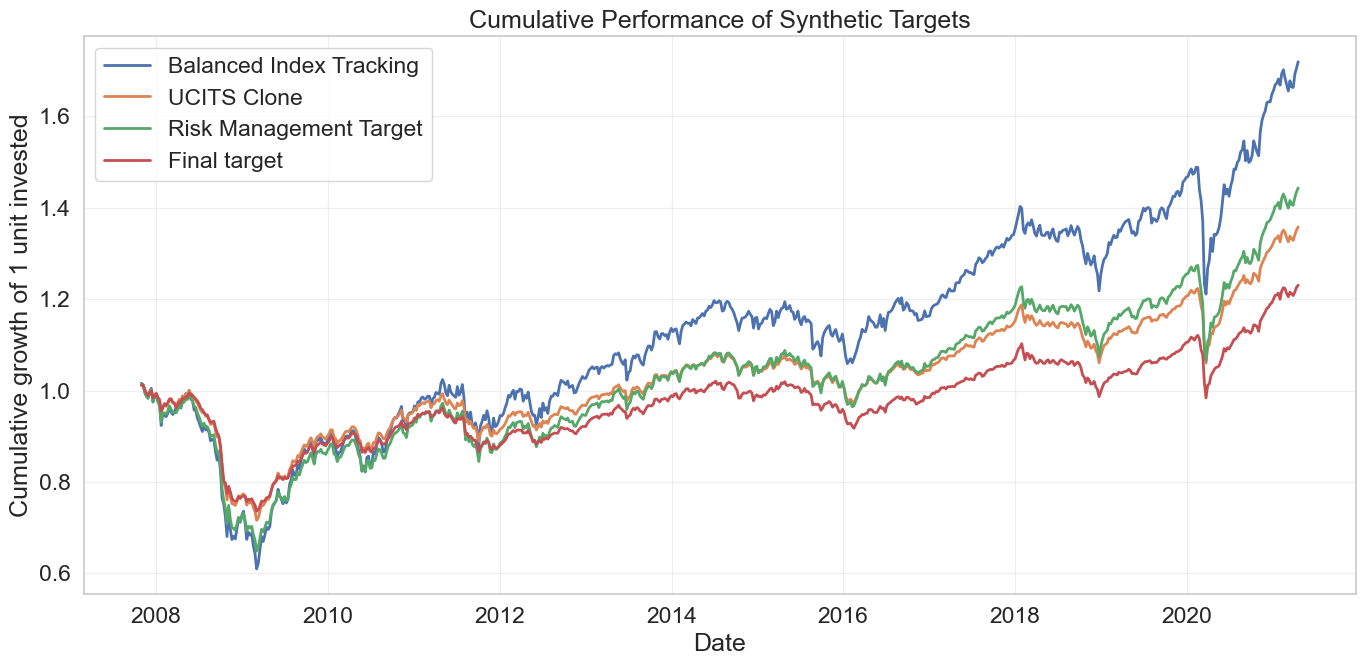

In [42]:
# Plot cumulative performance of all synthetic targets
all_targets_cumulative = (1 + all_synthetic_targets).cumprod()

plt.figure(figsize=(14, 7))

for col in all_targets_cumulative.columns:
    plt.plot(
        all_targets_cumulative.index,
        all_targets_cumulative[col],
        linewidth=2,
        label=col
    )

plt.title("Cumulative Performance of Synthetic Targets")
plt.xlabel("Date")
plt.ylabel("Cumulative growth of 1 unit invested")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Preliminary replicability check: correlations with futures
replicability_rows = []

for target_name in all_synthetic_targets.columns:
    target_series = all_synthetic_targets[target_name]
    
    corr_with_futures = futures_returns.corrwith(target_series).sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
    
    top_future = corr_with_futures.index[0]
    
    replicability_rows.append({
        "Target": target_name,
        "Top Future": top_future,
        "Top Future Description": variable_info.get(top_future, top_future),
        "Top Correlation": corr_with_futures.iloc[0],
        "Average Top 3 Abs Corr": corr_with_futures.abs().head(3).mean()
    })

replicability_summary = pd.DataFrame(replicability_rows)

replicability_summary["Top Correlation"] = replicability_summary["Top Correlation"].map(
    lambda x: f"{x:.3f}"
)
replicability_summary["Average Top 3 Abs Corr"] = replicability_summary[
    "Average Top 3 Abs Corr"
].map(lambda x: f"{x:.3f}")

print("Preliminary replicability summary:")
display(replicability_summary)

Preliminary replicability summary:


,Target,Top Future,Top Future Description,Top Correlation,Average Top 3 Abs Corr
0,Balanced Index Tracking,ES1 Comdty,S&P 500 Future,0.894,0.836
1,UCITS Clone,ES1 Comdty,S&P 500 Future,0.828,0.765
2,Risk Management Target,ES1 Comdty,S&P 500 Future,0.889,0.828
3,Final target,ES1 Comdty,S&P 500 Future,0.744,0.681


### 2.1 Autocorrelation check across different synthetic targets

In [44]:
# Ljung-Box test across all synthetic targets
synthetic_targets_ljung_box = []

for target_name in all_synthetic_targets.columns:
    series = all_synthetic_targets[target_name].dropna()
    
    lb_test = acorr_ljungbox(
        series,
        lags=[5, 10, 15, 20],
        return_df=True
    )
    
    for lag in [5, 10, 15, 20]:
        synthetic_targets_ljung_box.append({
            "Target": target_name,
            "Lag": lag,
            "Ljung-Box statistic": lb_test.loc[lag, "lb_stat"],
            "p-value": lb_test.loc[lag, "lb_pvalue"]
        })

synthetic_targets_ljung_box = pd.DataFrame(synthetic_targets_ljung_box)

synthetic_targets_ljung_box_display = synthetic_targets_ljung_box.copy()

synthetic_targets_ljung_box_display["Ljung-Box statistic"] = synthetic_targets_ljung_box_display[
    "Ljung-Box statistic"
].map(lambda x: f"{x:.2f}")

synthetic_targets_ljung_box_display["p-value"] = synthetic_targets_ljung_box_display[
    "p-value"
].map(lambda x: f"{x:.4f}")

print("Ljung-Box test across synthetic targets:")
display(synthetic_targets_ljung_box_display)

Ljung-Box test across synthetic targets:


,Target,Lag,Ljung-Box statistic,p-value
0,Balanced Index Tracking,5,2.89,0.7174
1,Balanced Index Tracking,10,17.00,0.0743
2,Balanced Index Tracking,15,27.38,0.0258
3,Balanced Index Tracking,20,34.45,0.0233
4,UCITS Clone,5,27.16,0.0001
5,UCITS Clone,10,38.12,0.0000
6,UCITS Clone,15,47.38,0.0000
7,UCITS Clone,20,54.63,0.0000
8,Risk Management Target,5,12.28,0.0312
9,Risk Management Target,10,23.90,0.0079


### 2.2 ARCH test across all synthetic targets


In [45]:
arch_targets_results = []

for target_name in all_synthetic_targets.columns:
    r = all_synthetic_targets[target_name].dropna().values
    
    lm_stat, lm_pval, _, _ = het_arch(r, nlags=5)
    
    arch_targets_results.append({
        "Target": target_name,
        "ARCH LM Statistic": lm_stat,
        "p-value": lm_pval,
        "Volatility Clustering": "Present" if lm_pval < 0.05 else "Not significant"
    })

arch_targets_results = pd.DataFrame(arch_targets_results)

arch_targets_display = arch_targets_results.copy()

arch_targets_display["ARCH LM Statistic"] = arch_targets_display[
    "ARCH LM Statistic"
].map(lambda x: f"{x:.2f}")

arch_targets_display["p-value"] = arch_targets_display[
    "p-value"
].map(lambda x: f"{x:.2e}")

print("ARCH test across synthetic targets:")
display(arch_targets_display)

ARCH test across synthetic targets:


,Target,ARCH LM Statistic,p-value,Volatility Clustering
0,Balanced Index Tracking,106.82,1.93e-21,Present
1,UCITS Clone,100.12,4.99e-20,Present
2,Risk Management Target,101.42,2.66e-20,Present
3,Final target,125.25,2.42e-25,Present


## 3. Further analysis on final chosen target

### 3.1 PCA

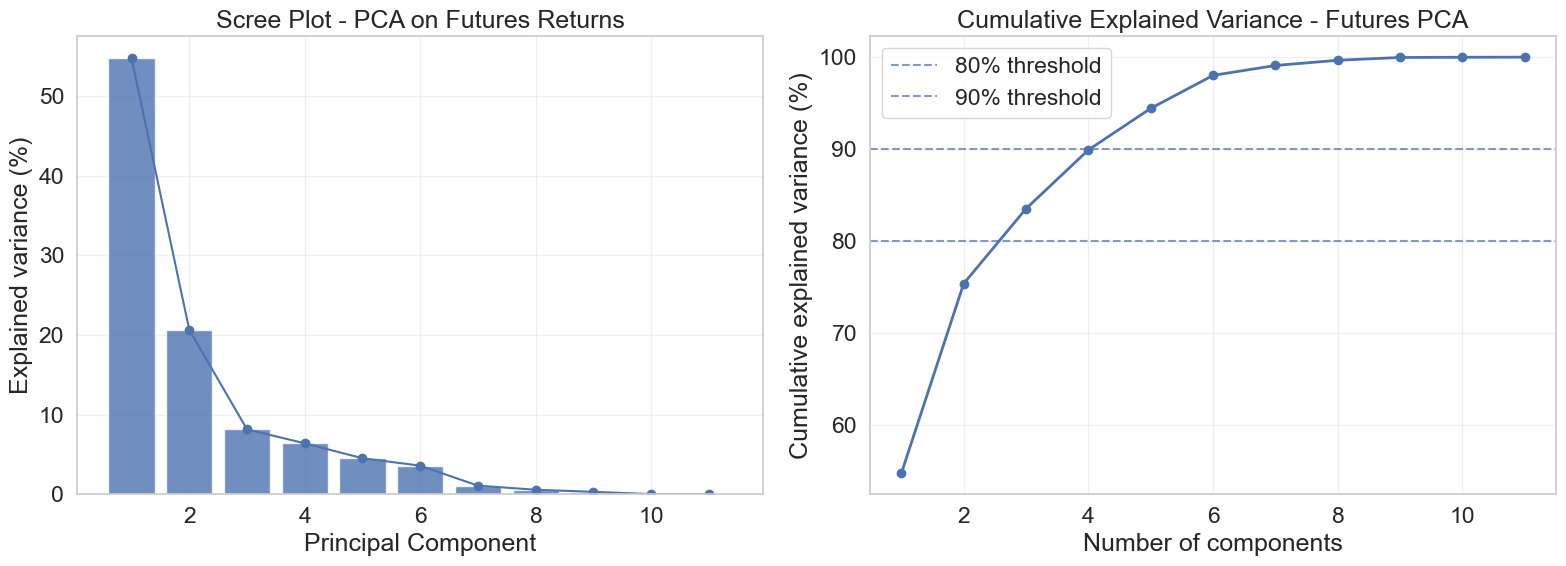

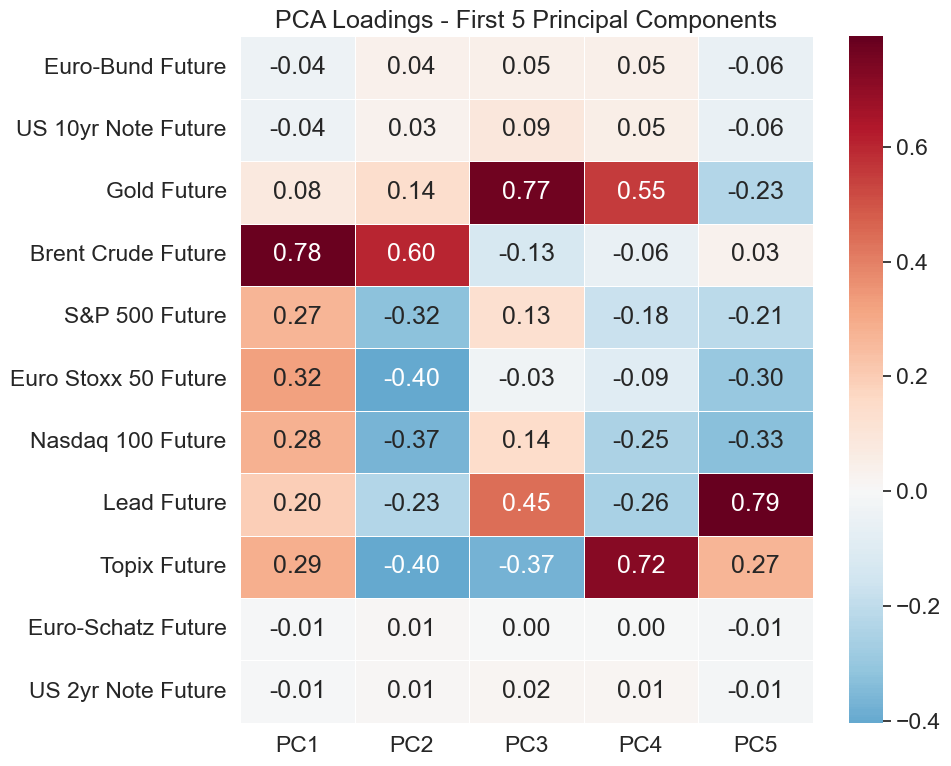

PCs needed to explain >= 80% of variance: 3
PCs needed to explain >= 90% of variance: 5
Variance explained by first 3 PCs      : 83.5%


In [46]:
from sklearn.decomposition import PCA

# PCA on futures returns
pca = PCA()
pca.fit(futures_returns.dropna())

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(1, len(explained) + 1), explained * 100, alpha=0.8)
ax1.plot(range(1, len(explained) + 1), explained * 100, "o-", linewidth=1.5)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained variance (%)")
ax1.set_title("Scree Plot - PCA on Futures Returns")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", linewidth=2)
ax2.axhline(80, linestyle="--", alpha=0.7, label="80% threshold")
ax2.axhline(90, linestyle="--", alpha=0.7, label="90% threshold")
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance (%)")
ax2.set_title("Cumulative Explained Variance - Futures PCA")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_[:5].T,
    index=[variable_info.get(c, c) for c in futures_returns.columns],
    columns=[f"PC{i+1}" for i in range(5)]
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("PCA Loadings - First 5 Principal Components")
plt.tight_layout()
plt.show()

n_80 = np.searchsorted(cumulative, 0.80) + 1
n_90 = np.searchsorted(cumulative, 0.90) + 1

print(f"PCs needed to explain >= 80% of variance: {n_80}")
print(f"PCs needed to explain >= 90% of variance: {n_90}")
print(f"Variance explained by first 3 PCs      : {cumulative[2] * 100:.1f}%")

### 3.2 Cumulative performance and drawdown

The cumulative-performance and drawdown plots provide a visual representation of the target’s long-term behavior. The cumulative curve shows the evolution of wealth invested in the synthetic target, while the drawdown chart highlights periods of stress and recovery.

This is useful because tracking quality should be evaluated not only through pointwise return errors, but also by checking whether the replica experiences similar loss periods and recovery patterns.

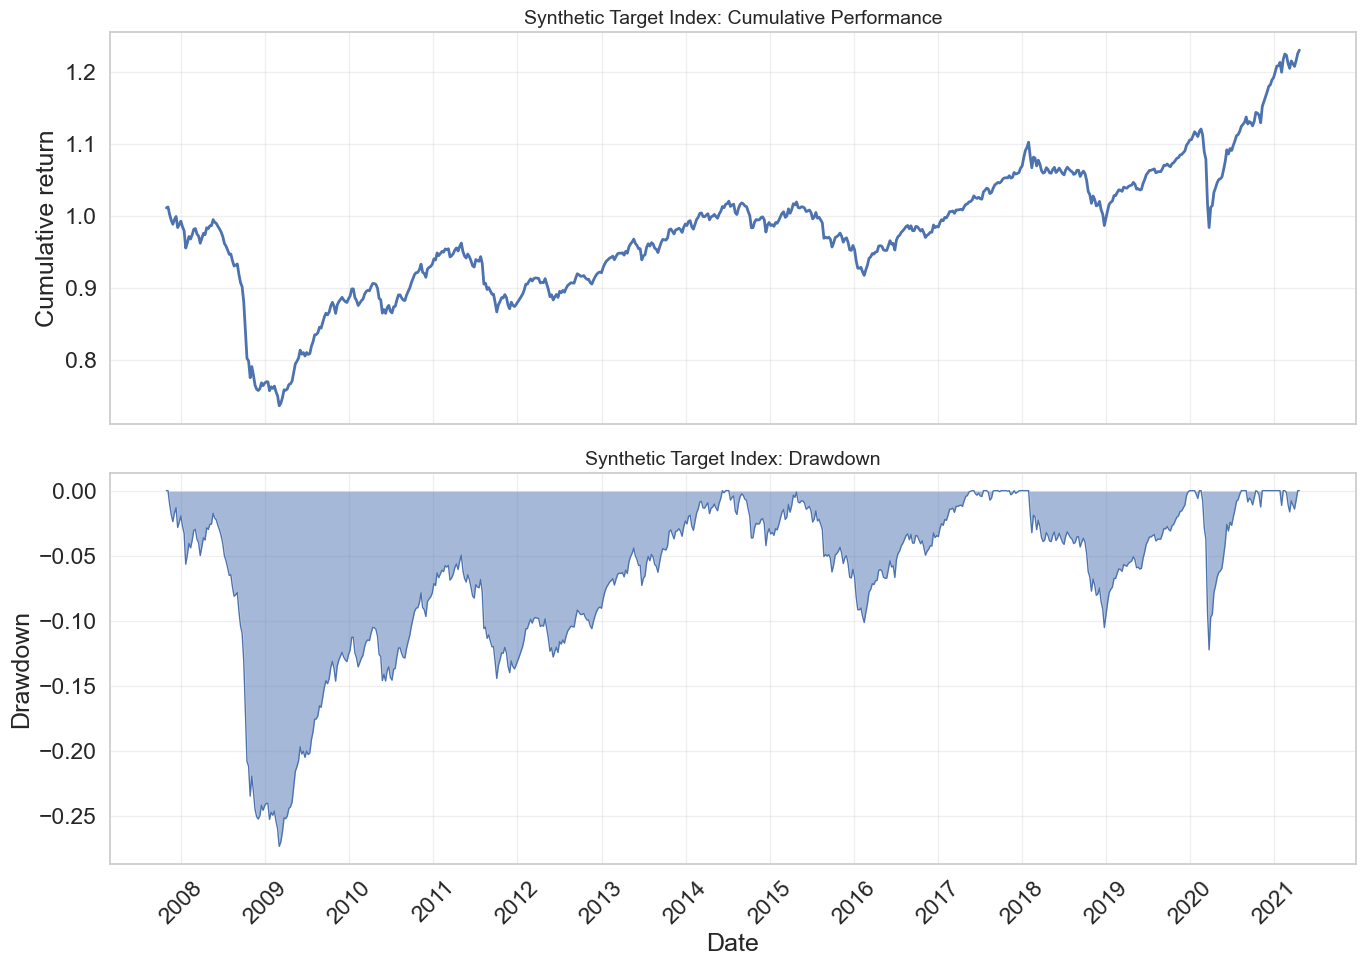

In [47]:
# Cumulative performance and drawdown

annual_factor = 52

cum_target = (1 + target_returns_aligned).cumprod()
drawdown = cum_target / cum_target.cummax() - 1


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(cum_target, linewidth=2)
ax1.set_title("Synthetic Target Index: Cumulative Performance", fontsize=14)
ax1.set_ylabel("Cumulative return")
ax1.grid(True, alpha=0.3)

ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.5)
ax2.plot(drawdown, linewidth=1)
ax2.set_title("Synthetic Target Index: Drawdown", fontsize=14)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Risk-return profile: target vs futures

This chart compares the synthetic target with the futures universe in annualized return-volatility space. The target lies in a relatively low-volatility region compared with most futures, which means that the clone will likely need diversified and scaled exposures rather than a simple one-to-one allocation to a single future.



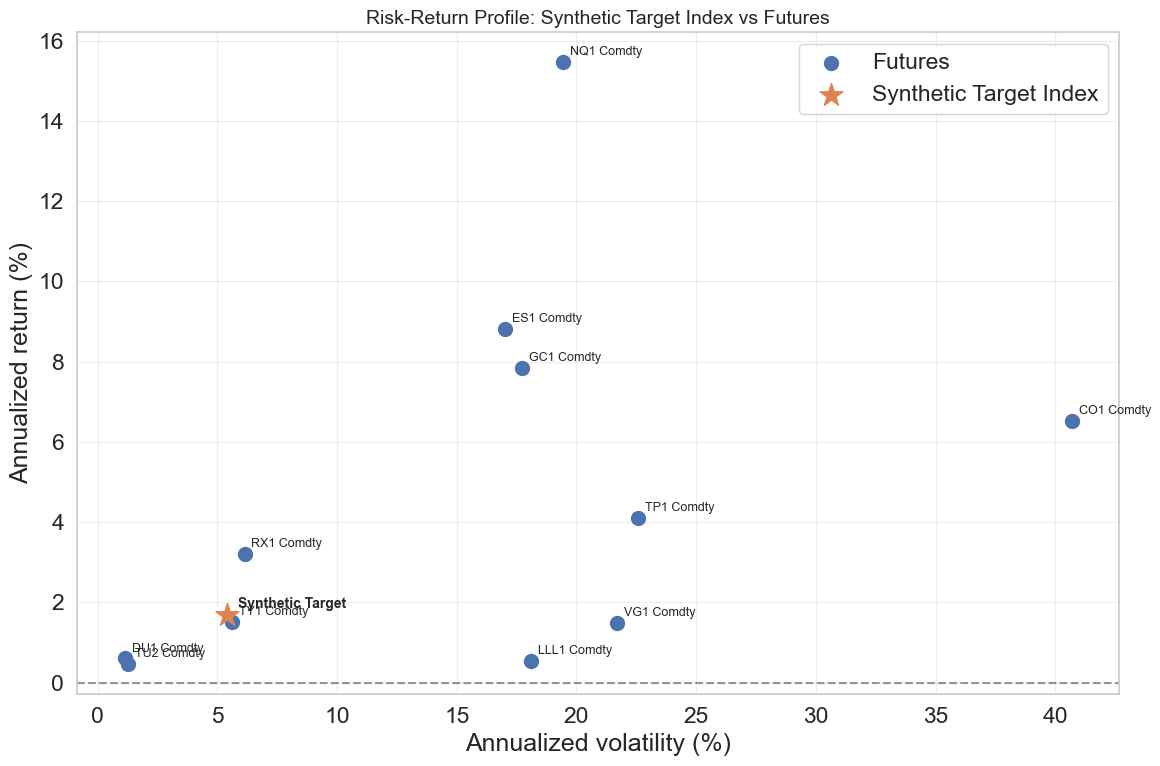

In [48]:
# Risk-return profile: Synthetic Target Index vs futures

ann_ret_fut = futures_returns.mean() * annual_factor
ann_vol_fut = futures_returns.std() * np.sqrt(annual_factor)

target_ret = target_returns_aligned.mean() * annual_factor
target_vol = target_returns_aligned.std() * np.sqrt(annual_factor)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    ann_vol_fut * 100,
    ann_ret_fut * 100,
    s=100,
    label="Futures"
)

for col in futures_returns.columns:
    ax.annotate(
        col,
        xy=(ann_vol_fut[col] * 100, ann_ret_fut[col] * 100),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.scatter(
    target_vol * 100,
    target_ret * 100,
    s=300,
    marker="*",
    label="Synthetic Target Index",
    zorder=4
)

ax.annotate(
    "Synthetic Target",
    xy=(target_vol * 100, target_ret * 100),
    xytext=(8, 5),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

ax.axhline(0, color="black", linestyle="--", alpha=0.4)
ax.set_title("Risk-Return Profile: Synthetic Target Index vs Futures", fontsize=14)
ax.set_xlabel("Annualized volatility (%)")
ax.set_ylabel("Annualized return (%)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 4 Ridge and Lasso Regression using Optuna


In [49]:
### EWMA VaR calculation
# This function calculates the Value at Risk (VaR) of a return series using an Exponentially 
# Weighted Moving Average (EWMA) approach to estimate volatility. 
# The EWMA method gives more weight to recent returns, allowing it to adapt to changing market conditions. 
# The function takes into account the confidence level, time horizon, and decay factor (lambda) for the variance estimation.


def calculate_var(returns, confidence=0.01, horizon=4, lam=0.94):
    returns = np.array(returns)

    # Initialise with sample variance
    ewma_var = np.var(returns, ddof=1)

    # Update recursively — older returns get weight λ^k, recent ones get (1-λ)
    for r in returns:
        ewma_var = lam * ewma_var + (1 - lam) * r**2

    sigma   = np.sqrt(ewma_var)
    z_score = stats.norm.ppf(confidence)    # ≈ -2.326 for 1%
    var     = -z_score * sigma * np.sqrt(horizon)
    return var

In [50]:
y = target_returns_aligned  # Target index returns
X = futures_returns.loc[y.index]  # Futures returns aligned with target
# VaR parameters
var_confidence = 0.01  # 1% VaR
var_horizon = 4  # 4 weeks (1 month)
max_var_threshold = 0.08  

# Convert to numpy arrays for easier indexing
X_values = X.values
y_values = y.values
dates_array = X.index.to_numpy()

In [51]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import MinMaxScaler

def run_rolling_regularized(model_type, alpha, rolling_window):
    # Initialize arrays to store results
    weights_history = []  
    replica_returns = []  
    target_dates = []  
    gross_exposures = []  
    var_values = []  
    scaling_factors = []  

    # Assuming X_values, y_values, and dates_array are pre-defined numpy arrays from your DataFrame
    X_values = X.values
    y_values = y.values
    dates_array = X.index.values

    for i in range(len(X) - rolling_window - 1):
        start_idx = i
        end_idx = i + rolling_window

        # Extract training data
        X_train = X_values[start_idx:end_idx]
        y_train = y_values[start_idx:end_idx]

        # Regularized models REQUIRE normalization
        scaler_X = MinMaxScaler()
        X_train_normalized = scaler_X.fit_transform(X_train)

        scaler_y = MinMaxScaler()
        y_train_normalized = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

        # Select and fit the requested model
        if model_type == 'Lasso':
            model = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000, tol=1e-4)
        elif model_type == 'Ridge':
            model = Ridge(alpha=alpha, fit_intercept=False, max_iter=10000, tol=1e-4)
        else:
            raise ValueError("model_type must be either 'Lasso' or 'Ridge'")

        model.fit(X_train_normalized, y_train_normalized)

        # Get the normalized weights and scale them back to original scale
        normalized_weights = model.coef_
        original_weights = normalized_weights / scaler_X.scale_

        scaling_factor = 1.0

        # VaR Risk Scaling Block 
        if len(replica_returns) >= 12:  
            historical_returns = []
            for j in range(max(0, len(replica_returns)-52), len(replica_returns)):
                hist_returns = X_values[end_idx-(len(replica_returns)-j)]
                weighted_return = np.dot(hist_returns, original_weights)
                historical_returns.append(weighted_return)

            # Assuming calculate_var is a pre-defined custom function
            var = calculate_var(
                historical_returns,
                confidence=0.01,
                horizon=4
            )

            if var > max_var_threshold:
                scaling_factor = max_var_threshold / var
                original_weights = original_weights * scaling_factor

                scaled_historical_returns = [ret * scaling_factor for ret in historical_returns]
                scaled_var = calculate_var(
                    scaled_historical_returns,
                    confidence=0.01,
                    horizon=4
                )
                var = scaled_var  

            var_values.append(var)
        else:
            var_values.append(np.nan)

        scaling_factors.append(scaling_factor)

        gross_exposure = np.sum(np.abs(original_weights))
        gross_exposures.append(gross_exposure)
        weights_history.append(original_weights)

        # Calculate out-of-sample return for t+1
        next_returns = X_values[end_idx]  
        replica_return = np.dot(next_returns, original_weights)
        replica_returns.append(replica_return)
        target_dates.append(dates_array[end_idx])

    replica_returns_series = pd.Series(replica_returns, index=target_dates)

    # Calculate cumulative returns
    aligned_target = y.loc[replica_returns_series.index]
    cumulative_target = (1 + aligned_target).cumprod()
    cumulative_replica = (1 + replica_returns_series).cumprod()

    # Calculate performance metrics (Assuming weekly data based on *52)
    replica_mean_return = replica_returns_series.mean() * 52  
    target_mean_return = aligned_target.mean() * 52  

    replica_vol = replica_returns_series.std() * np.sqrt(52)  
    target_vol = aligned_target.std() * np.sqrt(52)  

    replica_sharpe = replica_mean_return / replica_vol if replica_vol > 0 else 0
    target_sharpe = target_mean_return / target_vol if target_vol > 0 else 0

    tracking_error = (replica_returns_series - aligned_target).std() * np.sqrt(52)
    information_ratio = (replica_mean_return - target_mean_return) / tracking_error if tracking_error > 0 else 0

    replica_drawdown = 1 - cumulative_replica / cumulative_replica.cummax()
    target_drawdown = 1 - cumulative_target / cumulative_target.cummax()

    correlation = replica_returns_series.corr(aligned_target)
    avg_gross_exposure = np.mean(gross_exposures)
    avg_var = np.nanmean(var_values)

    return {
        'model_type': model_type,
        'alpha': alpha,
        'rolling_window': rolling_window,
        'replica_return': replica_mean_return,
        'target_return': target_mean_return,
        'replica_vol': replica_vol,
        'target_vol': target_vol,
        'replica_sharpe': replica_sharpe,
        'target_sharpe': target_sharpe,
        'tracking_error': tracking_error,
        'information_ratio': information_ratio,
        'correlation': correlation,
        'max_drawdown': replica_drawdown.max(),
        'avg_gross_exposure': avg_gross_exposure,
        'avg_var': avg_var,
        'replica_returns': replica_returns_series,
        'aligned_target': aligned_target,
        'cumulative_replica': cumulative_replica,
        'cumulative_target': cumulative_target,
        'gross_exposures': gross_exposures,
        'var_values': var_values,
        'scaling_factors': scaling_factors,
        'weights_history': weights_history
    }

In [52]:
# GRID SEARCH CELL
model_types = ['Lasso', 'Ridge']
alphas = [0.0001, 0.001, 0.01, 0.1] 
rolling_windows = [52, 104, 156]  # in weeks (1Y, 2Y, 3Y)


results = []
for model_type in model_types:
    for window in rolling_windows:
        for alpha in alphas:
            result = run_rolling_regularized(model_type, alpha, window)
            results.append(result)
            print(f"Completed: {model_type} | Window: {window} weeks | Alpha: {alpha}")

results_df = pd.DataFrame(results)

# Sort by tracking error (lower is better)
sorted_results = results_df.sort_values(by='tracking_error', ascending=True)

# Display top configurations
print("\nTop configurations by Tracking error:")
display(sorted_results[['model_type', 'alpha', 'rolling_window', 'information_ratio', 
                        'correlation', 'tracking_error', 'replica_sharpe', 
                        'avg_gross_exposure', 'avg_var']].head(10))

# Get the best configuration
best_config = sorted_results.iloc[0]
print(f"\nBest configuration: {best_config['model_type']} | Alpha={best_config['alpha']} | Window={best_config['rolling_window']} weeks")
print(f"Tracking error: {best_config['tracking_error']:.4f}")

Completed: Lasso | Window: 52 weeks | Alpha: 0.0001
Completed: Lasso | Window: 52 weeks | Alpha: 0.001
Completed: Lasso | Window: 52 weeks | Alpha: 0.01
Completed: Lasso | Window: 52 weeks | Alpha: 0.1
Completed: Lasso | Window: 104 weeks | Alpha: 0.0001
Completed: Lasso | Window: 104 weeks | Alpha: 0.001
Completed: Lasso | Window: 104 weeks | Alpha: 0.01
Completed: Lasso | Window: 104 weeks | Alpha: 0.1
Completed: Lasso | Window: 156 weeks | Alpha: 0.0001
Completed: Lasso | Window: 156 weeks | Alpha: 0.001
Completed: Lasso | Window: 156 weeks | Alpha: 0.01
Completed: Lasso | Window: 156 weeks | Alpha: 0.1
Completed: Ridge | Window: 52 weeks | Alpha: 0.0001
Completed: Ridge | Window: 52 weeks | Alpha: 0.001
Completed: Ridge | Window: 52 weeks | Alpha: 0.01
Completed: Ridge | Window: 52 weeks | Alpha: 0.1
Completed: Ridge | Window: 104 weeks | Alpha: 0.0001
Completed: Ridge | Window: 104 weeks | Alpha: 0.001
Completed: Ridge | Window: 104 weeks | Alpha: 0.01
Completed: Ridge | Window: 1

,model_type,alpha,rolling_window,information_ratio,correlation,tracking_error,replica_sharpe,avg_gross_exposure,avg_var
9,Lasso,0.0010,156,-0.059326,0.679232,0.035326,0.765195,0.214566,0.019624
8,Lasso,0.0001,156,-0.051708,0.678867,0.035559,0.718443,0.246500,0.020905
5,Lasso,0.0010,104,-0.330892,0.677298,0.035572,0.571813,0.193442,0.018537
23,Ridge,0.1000,156,-0.039827,0.671005,0.035984,0.724210,0.244868,0.021365
22,Ridge,0.0100,156,-0.055948,0.669675,0.036150,0.695625,0.256209,0.021304
10,Lasso,0.0100,156,-0.123044,0.660724,0.036201,0.825324,0.183512,0.016924
21,Ridge,0.0010,156,-0.057752,0.668647,0.036228,0.690713,0.257982,0.021313
20,Ridge,0.0001,156,-0.057934,0.668525,0.036237,0.690184,0.258171,0.021315
4,Lasso,0.0001,104,-0.331670,0.661775,0.036263,0.537841,0.229092,0.019582
19,Ridge,0.1000,104,-0.296888,0.660977,0.036287,0.581183,0.220718,0.019744



Best configuration: Lasso | Alpha=0.001 | Window=156 weeks
Tracking error: 0.0353



Detailed metrics for the best configuration (Lasso):


,Metric,Target,Replica
0,Annualized return,2.83%,2.62%
1,Annualized volatility,4.81%,3.43%
2,Sharpe ratio,0.59,0.77
3,Max Drawdown,6.30%,6.30%
4,Tracking Error,N/A,3.53%
5,Information ratio,N/A,-0.06
6,Correlation,N/A,0.6792
7,Average gross exposure,N/A,0.2146
8,"Average VaR (1%, 1M)",N/A,1.96%


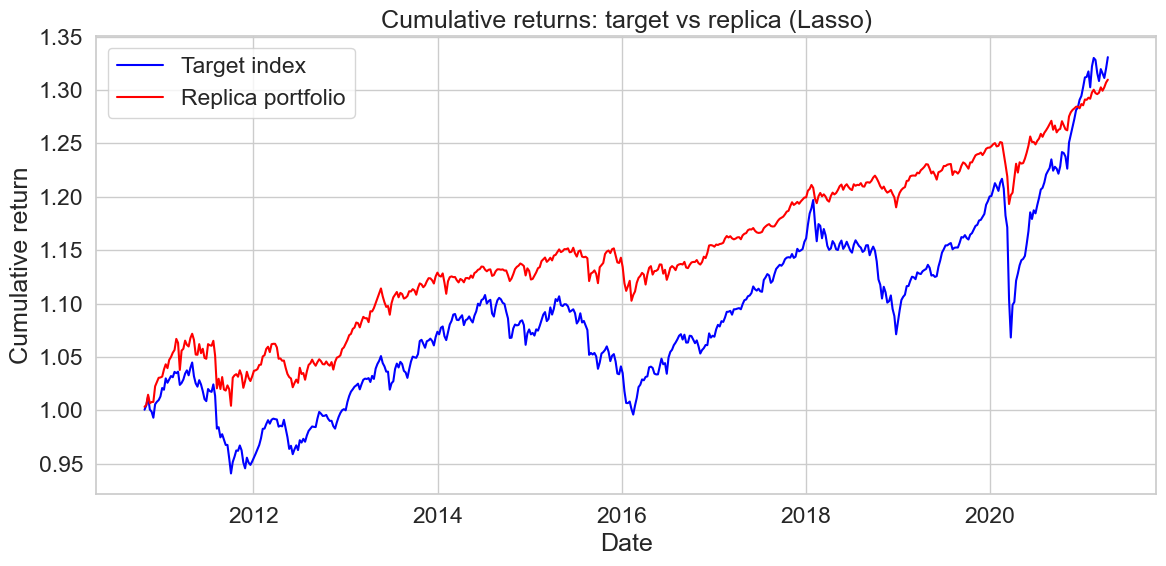

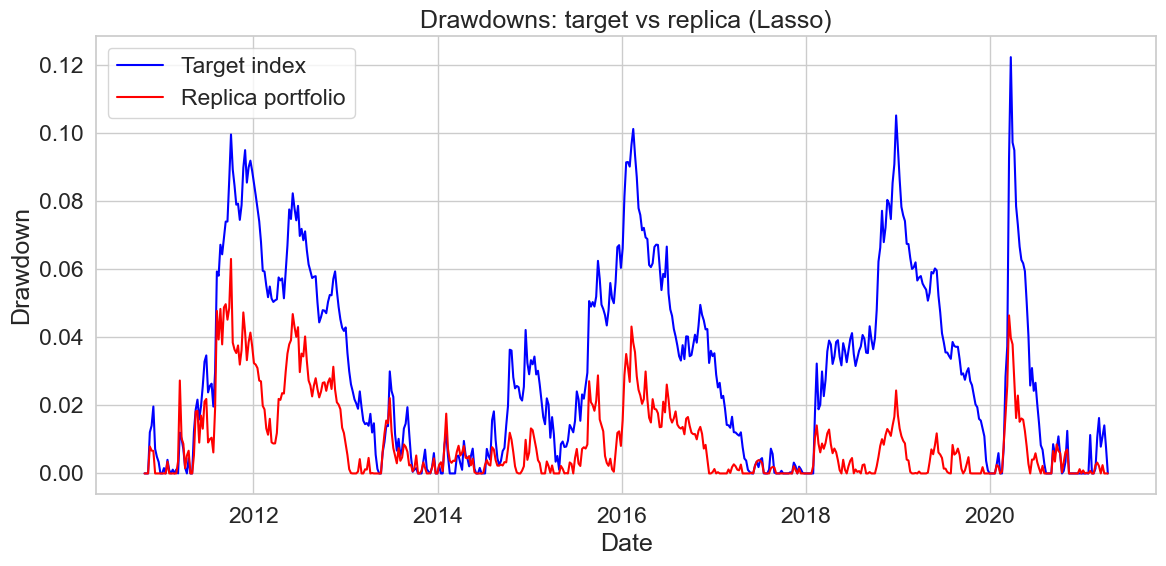

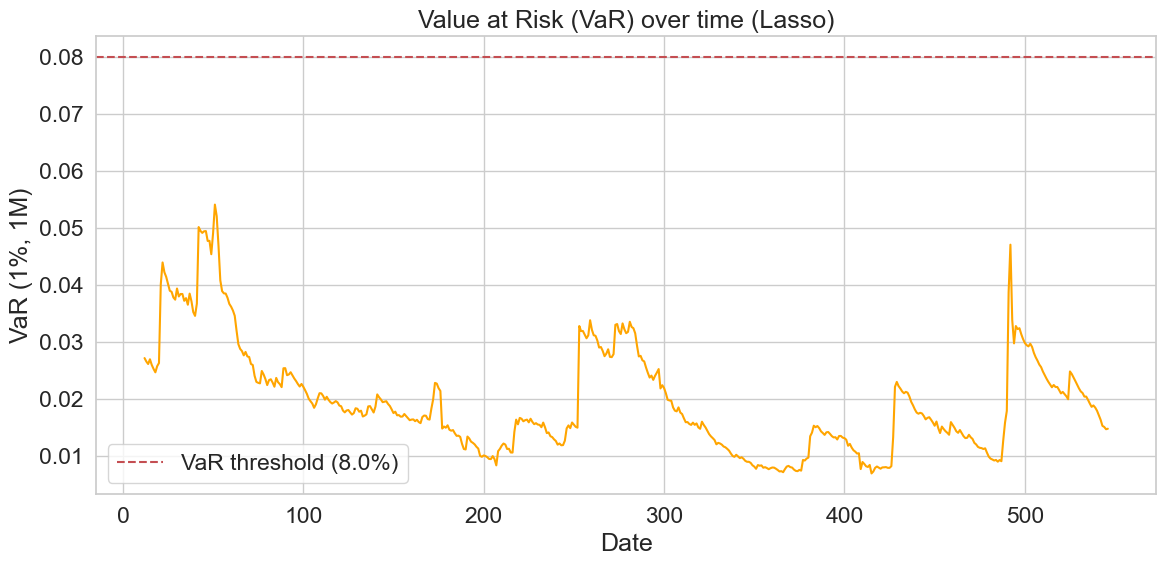

In [53]:
# PLOT FOR THE BEST CONFIGURATION


# Create detailed metrics table
metrics = pd.DataFrame({
    'Metric': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
               'Max Drawdown', 'Tracking Error', 'Information ratio',
               'Correlation', 'Average gross exposure', 'Average VaR (1%, 1M)'],
    'Target': [f"{best_config['target_return']*100:.2f}%",
               f"{best_config['target_vol']*100:.2f}%",
               f"{best_config['target_sharpe']:.2f}",
               f"{best_config['max_drawdown']*100:.2f}%",
               "N/A", "N/A", "N/A", "N/A", "N/A"],
    'Replica': [f"{best_config['replica_return']*100:.2f}%",
                f"{best_config['replica_vol']*100:.2f}%",
                f"{best_config['replica_sharpe']:.2f}",
                f"{best_config['max_drawdown']*100:.2f}%",
                f"{best_config['tracking_error']*100:.2f}%",
                f"{best_config['information_ratio']:.2f}",
                f"{best_config['correlation']:.4f}",
                f"{best_config['avg_gross_exposure']:.4f}",
                f"{best_config['avg_var']*100:.2f}%"]
})

print(f"\nDetailed metrics for the best configuration ({best_config['model_type']}):")
display(metrics)

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(best_config['cumulative_target'], label='Target index', color='blue')
plt.plot(best_config['cumulative_replica'], label='Replica portfolio', color='red')
plt.title(f"Cumulative returns: target vs replica ({best_config['model_type']})")
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot drawdowns
plt.figure(figsize=(12, 6))
target_dd_plot = 1 - best_config['cumulative_target'] / best_config['cumulative_target'].cummax()
replica_dd_plot = 1 - best_config['cumulative_replica'] / best_config['cumulative_replica'].cummax()
plt.plot(target_dd_plot, label='Target index', color='blue')
plt.plot(replica_dd_plot, label='Replica portfolio', color='red')
plt.title(f"Drawdowns: target vs replica ({best_config['model_type']})")
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot VaR over time
plt.figure(figsize=(12, 6))
plt.plot(best_config['var_values'], color='orange')
plt.axhline(y=max_var_threshold, color='r', linestyle='--', label=f'VaR threshold ({max_var_threshold*100}%)')
plt.title(f"Value at Risk (VaR) over time ({best_config['model_type']})")
plt.xlabel('Date')
plt.ylabel('VaR (1%, 1M)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
